In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:86% !important;}
div.cell.code_cell.rendered{width:100%;}
div.CodeMirror {font-family:Consolas; font-size:12pt;}
div.output {font-size:15pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:15px;}
</style>
"""))

<font size=5, color='red'>ch04_RNN(Recurrent Neural Network 순환신경망)</font>
# 1. 문맥을 이용하여 모델 만들기

## 1. 데이터 전처리


In [32]:
text = '''경마장에 있는 말이 뛰고 있다
그의 말이 법이다
가는 말이 고아야 오는 말이 곱다'''
text1 = "장마철이 오고 있다"

In [13]:
from keras_preprocessing.text import Tokenizer
t = Tokenizer()
t.fit_on_texts([text, text1])
encoded = t.texts_to_sequences([text, text1])
print(encoded)
print(t.word_index) # 내가 필요한 건 결과물 딕셔너리의 values를 갖는 key로 이를 위해 자료를 수정해줘야한다.

[[3, 4, 1, 5, 2, 6, 1, 7, 8, 1, 9, 10, 1, 11], [12, 13, 2]]
{'말이': 1, '있다': 2, '경마장에': 3, '있는': 4, '뛰고': 5, '그의': 6, '없이다': 7, '가는': 8, '고아야': 9, '오는': 10, '곱다': 11, '장마철이': 12, '오고': 13}


In [33]:
from keras_preprocessing.text import Tokenizer
t = Tokenizer()
t.fit_on_texts([text])
encoded = t.texts_to_sequences([text])
print(encoded)
print(t.word_index) # 내가 필요한 건 결과물 딕셔너리의 values를 갖는 key로 이를 위해 자료를 수정해줘야한다.

[[2, 3, 1, 4, 5, 6, 1, 7, 8, 1, 9, 10, 1, 11]]
{'말이': 1, '경마장에': 2, '있는': 3, '뛰고': 4, '있다': 5, '그의': 6, '법이다': 7, '가는': 8, '고아야': 9, '오는': 10, '곱다': 11}


In [34]:
# 문자열 리스트를 인덱스 시퀀스로 변환
print(t.texts_to_sequences(['경마장에 말이 있다','말이 뛴다'])) # 반드시 list형태로 넣어야한다. => 반환은 2차원 리스트
print(t.texts_to_sequences(['가는 말이 곱다'])[0])

[[2, 1, 5], [1]]
[8, 1, 11]


In [50]:
for key, value in t.index_word.items() :
    print(key, value)
t.index_word

1 말이
2 경마장에
3 있는
4 뛰고
5 있다
6 그의
7 법이다
8 가는
9 고아야
10 오는
11 곱다


{1: '말이',
 2: '경마장에',
 3: '있는',
 4: '뛰고',
 5: '있다',
 6: '그의',
 7: '법이다',
 8: '가는',
 9: '고아야',
 10: '오는',
 11: '곱다'}

In [53]:
# 학습을 시키기 위해 기존의 text를 ['경마장에 있는','경마장에 있는 말이',.....] 
sequences = []
for line in text.split('\n') :
    print('원 문장 :',line)
    encoded = t.texts_to_sequences([line])[0]
    print('encoded된 문장 :',encoded)
    for i in range(len(encoded)-1) : # i는 시작 인덱스
        for j in range(i+2, len(encoded)+1) : # j는 끝나는 index 바로 뒤
            sequences.append(encoded[i:j])
print(sequences)
print('sequences와 해석 출력')
for sequence in sequences :
    for word_seq in sequence :
        for word, index in t.word_index.items() :
            if word_seq == index :
                print(f'{word_seq}:{word}', end=' ')
    print()

원 문장 : 경마장에 있는 말이 뛰고 있다
encoded된 문장 : [2, 3, 1, 4, 5]
원 문장 : 그의 말이 법이다
encoded된 문장 : [6, 1, 7]
원 문장 : 가는 말이 고아야 오는 말이 곱다
encoded된 문장 : [8, 1, 9, 10, 1, 11]
[[2, 3], [2, 3, 1], [2, 3, 1, 4], [2, 3, 1, 4, 5], [3, 1], [3, 1, 4], [3, 1, 4, 5], [1, 4], [1, 4, 5], [4, 5], [6, 1], [6, 1, 7], [1, 7], [8, 1], [8, 1, 9], [8, 1, 9, 10], [8, 1, 9, 10, 1], [8, 1, 9, 10, 1, 11], [1, 9], [1, 9, 10], [1, 9, 10, 1], [1, 9, 10, 1, 11], [9, 10], [9, 10, 1], [9, 10, 1, 11], [10, 1], [10, 1, 11], [1, 11]]
sequences와 해석 출력
2:경마장에 3:있는 
2:경마장에 3:있는 1:말이 
2:경마장에 3:있는 1:말이 4:뛰고 
2:경마장에 3:있는 1:말이 4:뛰고 5:있다 
3:있는 1:말이 
3:있는 1:말이 4:뛰고 
3:있는 1:말이 4:뛰고 5:있다 
1:말이 4:뛰고 
1:말이 4:뛰고 5:있다 
4:뛰고 5:있다 
6:그의 1:말이 
6:그의 1:말이 7:법이다 
1:말이 7:법이다 
8:가는 1:말이 
8:가는 1:말이 9:고아야 
8:가는 1:말이 9:고아야 10:오는 
8:가는 1:말이 9:고아야 10:오는 1:말이 
8:가는 1:말이 9:고아야 10:오는 1:말이 11:곱다 
1:말이 9:고아야 
1:말이 9:고아야 10:오는 
1:말이 9:고아야 10:오는 1:말이 
1:말이 9:고아야 10:오는 1:말이 11:곱다 
9:고아야 10:오는 
9:고아야 10:오는 1:말이 
9:고아야 10:오는 1:말이 11:곱다 
10:오는 1:말이 
10:오는 1:말이 11:곱다 
1:말이 

In [51]:
sequences = []
for line in text.split('\n') :
    print('원 문장 :',line)
    encoded = t.texts_to_sequences([line])[0]
    print('encoded된 문장 :',encoded)
    for i in range(len(encoded)-1) : # i는 시작 인덱스
        for j in range(i+2, len(encoded)+1) : # j는 끝나는 index 바로 뒤
            sequences.append(encoded[i:j])
print(sequences)
print('sequences와 해석 출력')
for sequence in sequences :
    temp = ''
    for word_seq in sequence :
        temp += t.index_word.get(word_seq)
    print(temp)

원 문장 : 경마장에 있는 말이 뛰고 있다
encoded된 문장 : [2, 3, 1, 4, 5]
원 문장 : 그의 말이 법이다
encoded된 문장 : [6, 1, 7]
원 문장 : 가는 말이 고아야 오는 말이 곱다
encoded된 문장 : [8, 1, 9, 10, 1, 11]
[[2, 3], [2, 3, 1], [2, 3, 1, 4], [2, 3, 1, 4, 5], [3, 1], [3, 1, 4], [3, 1, 4, 5], [1, 4], [1, 4, 5], [4, 5], [6, 1], [6, 1, 7], [1, 7], [8, 1], [8, 1, 9], [8, 1, 9, 10], [8, 1, 9, 10, 1], [8, 1, 9, 10, 1, 11], [1, 9], [1, 9, 10], [1, 9, 10, 1], [1, 9, 10, 1, 11], [9, 10], [9, 10, 1], [9, 10, 1, 11], [10, 1], [10, 1, 11], [1, 11]]
sequences와 해석 출력
경마장에있는
경마장에있는말이
경마장에있는말이뛰고
경마장에있는말이뛰고있다
있는말이
있는말이뛰고
있는말이뛰고있다
말이뛰고
말이뛰고있다
뛰고있다
그의말이
그의말이법이다
말이법이다
가는말이
가는말이고아야
가는말이고아야오는
가는말이고아야오는말이
가는말이고아야오는말이곱다
말이고아야
말이고아야오는
말이고아야오는말이
말이고아야오는말이곱다
고아야오는
고아야오는말이
고아야오는말이곱다
오는말이
오는말이곱다
말이곱다


In [62]:
print([len(seq) for seq in sequences])
my_len = max(len(seq) for seq in sequences)
print(my_len)
# len([len(seq) for seq in sequences]) # 28

[2, 3, 4, 5, 2, 3, 4, 2, 3, 2, 2, 3, 2, 2, 3, 4, 5, 6, 2, 3, 4, 5, 2, 3, 4, 2, 3, 2]
6


In [63]:
# sequences를 훈련 가능하도록 모두 my_len(6) 사이즈로 조정
from tensorflow.keras.preprocessing.sequence import pad_sequences
padded_sequences = pad_sequences(sequences=sequences, # 패딩처리 할 대상
                                padding = 'pre', # padding을 앞에 pre 뒤에 post
                                maxlen = my_len, # 최대 6길이로 잘라서 조정, 미설정 시 가장 큰 값으로 자동 수정
                                truncating = 'pre', # 만약 최대길이로 조정해야 하면 앞을 자른다 pre 뒤를 자른다 post
                                value = 0, # padding을 어떤 값으로 할 것인가
                                ) 
padded_sequences.shape, type(padded_sequences)

((28, 6), numpy.ndarray)

In [70]:
# 독립변수(X), 타겟변수(y) 분리
X = padded_sequences[:,:-1]
y = padded_sequences[:,-1]
X.shape, y.shape

((28, 5), (28,))

In [73]:
# X를 컴퓨터가 임베딩 작업할 때 필요한 입력 bit 수 (필요한 단어 갯수) => index=0 일때 고려하여 len(t.word_index) + 1사용(실제 단어수 + 1) 
# 단어수 + 1
input_dim = len(t.word_index) + 1
input_dim

12

In [78]:
# y 원핫인코딩
from tensorflow.keras.utils import to_categorical
Y = to_categorical(y, input_dim)
X.shape, Y.shape, input_dim

((28, 5), (28, 12), 12)

## 2. 모델 생성하기

In [81]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding # Xi의 원핫인코딩한 희소행렬 반환 ex) 가는 : 1 => [0,1,0,0,0,0] 형태로
from tensorflow.keras.layers import SimpleRNN, Dense, Input, Dropout
import matplotlib.pyplot as plt

model = Sequential()
model.add(Embedding(input_dim=input_dim, # 학습한 text의 총 단어수 + 1
                   output_dim=10, # embedding 후 출력 개수
                   input_length=X.shape[1], # 입력(X) 단어의 수 
                   ))
model.add(SimpleRNN(units = 32,
                   ))
model.add(Dense(12, activation='softmax'))
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 5, 10)             120       
                                                                 
 simple_rnn (SimpleRNN)      (None, 32)                1376      
                                                                 
 dense (Dense)               (None, 12)                396       
                                                                 
Total params: 1,892
Trainable params: 1,892
Non-trainable params: 0
_________________________________________________________________


## 3. 모델 학습 과정 설정

In [84]:
model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

## 4. 모델 학습

In [85]:
hist = model.fit(X,Y, epochs=300, verbose=2)

Epoch 1/300
1/1 - 1s - loss: 2.5009 - accuracy: 0.0714 - 1s/epoch - 1s/step
Epoch 2/300
1/1 - 0s - loss: 2.4874 - accuracy: 0.1071 - 4ms/epoch - 4ms/step
Epoch 3/300
1/1 - 0s - loss: 2.4742 - accuracy: 0.2143 - 4ms/epoch - 4ms/step
Epoch 4/300
1/1 - 0s - loss: 2.4613 - accuracy: 0.3214 - 3ms/epoch - 3ms/step
Epoch 5/300
1/1 - 0s - loss: 2.4486 - accuracy: 0.3214 - 3ms/epoch - 3ms/step
Epoch 6/300
1/1 - 0s - loss: 2.4358 - accuracy: 0.3214 - 0s/epoch - 0s/step
Epoch 7/300
1/1 - 0s - loss: 2.4229 - accuracy: 0.2857 - 13ms/epoch - 13ms/step
Epoch 8/300
1/1 - 0s - loss: 2.4098 - accuracy: 0.2857 - 2ms/epoch - 2ms/step
Epoch 9/300
1/1 - 0s - loss: 2.3963 - accuracy: 0.2857 - 13ms/epoch - 13ms/step
Epoch 10/300
1/1 - 0s - loss: 2.3823 - accuracy: 0.2857 - 5ms/epoch - 5ms/step
Epoch 11/300
1/1 - 0s - loss: 2.3678 - accuracy: 0.2857 - 6ms/epoch - 6ms/step
Epoch 12/300
1/1 - 0s - loss: 2.3526 - accuracy: 0.2857 - 6ms/epoch - 6ms/step
Epoch 13/300
1/1 - 0s - loss: 2.3367 - accuracy: 0.2857 - 4ms

Epoch 105/300
1/1 - 0s - loss: 1.0487 - accuracy: 0.7143 - 0s/epoch - 0s/step
Epoch 106/300
1/1 - 0s - loss: 1.0365 - accuracy: 0.7143 - 5ms/epoch - 5ms/step
Epoch 107/300
1/1 - 0s - loss: 1.0246 - accuracy: 0.7143 - 4ms/epoch - 4ms/step
Epoch 108/300
1/1 - 0s - loss: 1.0129 - accuracy: 0.7143 - 9ms/epoch - 9ms/step
Epoch 109/300
1/1 - 0s - loss: 1.0015 - accuracy: 0.7143 - 0s/epoch - 0s/step
Epoch 110/300
1/1 - 0s - loss: 0.9903 - accuracy: 0.7143 - 9ms/epoch - 9ms/step
Epoch 111/300
1/1 - 0s - loss: 0.9794 - accuracy: 0.7143 - 6ms/epoch - 6ms/step
Epoch 112/300
1/1 - 0s - loss: 0.9687 - accuracy: 0.7143 - 0s/epoch - 0s/step
Epoch 113/300
1/1 - 0s - loss: 0.9581 - accuracy: 0.7143 - 2ms/epoch - 2ms/step
Epoch 114/300
1/1 - 0s - loss: 0.9478 - accuracy: 0.7143 - 0s/epoch - 0s/step
Epoch 115/300
1/1 - 0s - loss: 0.9377 - accuracy: 0.7143 - 17ms/epoch - 17ms/step
Epoch 116/300
1/1 - 0s - loss: 0.9277 - accuracy: 0.7143 - 7ms/epoch - 7ms/step
Epoch 117/300
1/1 - 0s - loss: 0.9179 - accura

Epoch 208/300
1/1 - 0s - loss: 0.4217 - accuracy: 0.8929 - 0s/epoch - 0s/step
Epoch 209/300
1/1 - 0s - loss: 0.4190 - accuracy: 0.8929 - 6ms/epoch - 6ms/step
Epoch 210/300
1/1 - 0s - loss: 0.4163 - accuracy: 0.8929 - 3ms/epoch - 3ms/step
Epoch 211/300
1/1 - 0s - loss: 0.4137 - accuracy: 0.8929 - 2ms/epoch - 2ms/step
Epoch 212/300
1/1 - 0s - loss: 0.4112 - accuracy: 0.8929 - 0s/epoch - 0s/step
Epoch 213/300
1/1 - 0s - loss: 0.4086 - accuracy: 0.8929 - 15ms/epoch - 15ms/step
Epoch 214/300
1/1 - 0s - loss: 0.4061 - accuracy: 0.8929 - 4ms/epoch - 4ms/step
Epoch 215/300
1/1 - 0s - loss: 0.4036 - accuracy: 0.8929 - 4ms/epoch - 4ms/step
Epoch 216/300
1/1 - 0s - loss: 0.4012 - accuracy: 0.8929 - 3ms/epoch - 3ms/step
Epoch 217/300
1/1 - 0s - loss: 0.3988 - accuracy: 0.8929 - 4ms/epoch - 4ms/step
Epoch 218/300
1/1 - 0s - loss: 0.3964 - accuracy: 0.8929 - 5ms/epoch - 5ms/step
Epoch 219/300
1/1 - 0s - loss: 0.3941 - accuracy: 0.8929 - 0s/epoch - 0s/step
Epoch 220/300
1/1 - 0s - loss: 0.3918 - accu

## 5. 모델 학습과정 살펴보기

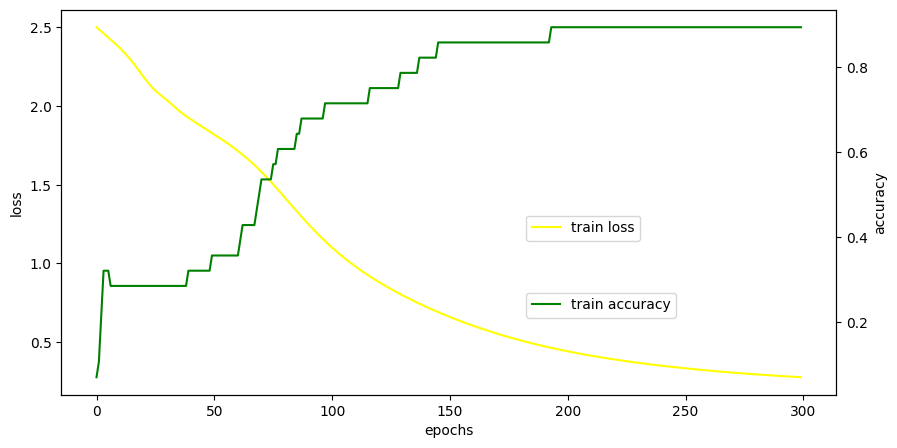

In [87]:
# 모델 학습 과정 확인하기
hist.history.keys() # loss accuracy val_loss val_accuracy
fig, loss_ax = plt.subplots(figsize=(10,5))
loss_ax.plot(hist.history.get('loss'), color='yellow',label='train loss')
# loss_ax.plot(hist.history.get('val_loss'), color='red',label='val loss')
loss_ax.set_xlabel('epochs')
loss_ax.set_ylabel('loss')
loss_ax.legend(loc=(0.6,0.4))
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history.get('accuracy'),color='green',label='train accuracy')
# acc_ax.plot(hist.history.get('val_accuracy'),color='blue',label='val binary accuracy')
acc_ax.set_ylabel('accuracy')
acc_ax.legend(loc=(0.6,0.2))

## 6. 모델 평가하기 => 데이터가 작아 불가

## 7. 모델 사용하기

In [114]:
# 경마장에 -> 있는 -> 말이 -> 뛰고
question = input('단어를 입력하세요 : ') # 여기서 학습되지 않은 데이터를 넣어도 결과가 출력 -> halumination 원리와 동일
encoded = t.texts_to_sequences([question])[0]
input_data = pad_sequences([encoded], maxlen = my_len-1, padding='pre') # maxlen = my_len-1 : X와 y데이터 분할 고려
print('입력데이터 :',input_data)
result = model.predict(input_data,verbose=0).argmax()
print('예측된 단어는',t.index_word.get(result,'??'),'입니다')

단어를 입력하세요 : 가는 말이
입력데이터 : [[0 0 0 8 1]]
예측된 단어는 고아야 입니다


# 2. 다음 문맥 예측해보기

In [136]:
# "경마장에" -> 있는 : 경마장에 있는 -> 말이 :경마장에 있는 말이 -> 뛰고 : 경마장에 있는 말이 뛰고 -> 있다 : 경마장에 있는 말이 뛰고 있다
# "----" 이후에 올 단어 ? 예측
def sentence_generatrion(current_word, n=3) :
    print('입력된 단어 :',current_word)
    for i in range(n) :
        encoded = t.texts_to_sequences([current_word])[0]
        input_data = pad_sequences([encoded], maxlen = my_len-1, padding='pre')
        result = model.predict(input_data,verbose=0).argmax()
        word_form = t.index_word.get(result,'??')
        current_word += ' ' + word_form
#         print(f'{i+1}번째 생성 문맥 : {current_word}({encoded} {result})')
    return current_word
    
sentence_generatrion('경마장에',3)

입력된 단어 : 경마장에


'경마장에 있는 말이 뛰고'

In [137]:
sentence_generatrion('말')

입력된 단어 : 말


'말 말이 고아야 오는'